# Monte Carlo Example

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/monte_carlo_example.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-22*

## Learning objectives

- Use a *Monte Carlo* approach to characterize the distribution of a statistic when no convenient closed-form test applies.
- Draw many synthetic samples from an assumed underlying distribution, compute the statistic of interest for each, and read probabilities directly off the resulting histogram.
- Practice translating a real-world question ("how rare is a 2.2σ maximum in 31 daily values?") into a Monte Carlo experiment.


## The problem

This example comes from the "Monte Carlo simulation" section of Chapter 1 of the lecture notes.

In January (31 days), the maximum daily temperature was 2.2 standard deviations from the climatological mean. If daily temperatures are approximately normal, *how rare is it to see a maximum of 2.2σ or greater in 31 daily samples?*


## The approach

We have textbook tests for the sample mean and even the sample variance — but we want a probability statement about the **maximum**. There are dedicated extreme-value tests for that, but since the title of this notebook is "Monte Carlo", let's just do it directly.

Because we are willing to assume the underlying population is normal, we can simulate it: draw many synthetic 31-day samples from a standard normal, record the maximum of each, and look at the resulting distribution of maxima. The probability of exceeding 2.2 is then just the fraction of synthetic maxima that did.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

rng = np.random.default_rng(33)

Set our two key knobs. `drawn_max` is the observed January maximum (in standard deviations from the mean) and `sample_length` is the number of daily values in each sample (`N = 31`).


In [2]:
drawn_max = 2.2
sample_length = 31

Build a big "population bucket" `Z` of standard-normal values to draw from, and allocate an array `M` to hold the maxima of our 100,000 synthetic samples.


In [3]:
Z = rng.standard_normal((1_000_000, 1))
M = np.empty([100_000, 1])

## Monte Carlo loop

For each of the 100,000 trials: randomly grab `N = 31` values from the population bucket, take their maximum, and store it.


In [4]:
for iloop in range(np.size(M)):
    ip = rng.integers(low=0, high=Z.shape[0], size=sample_length)
    M[iloop] = np.max(Z[ip])

## Visualize the distribution of maxima

Plot the histogram of our 100,000 synthetic maxima, with the observed maximum (2.2) overlaid as a red dashed line.


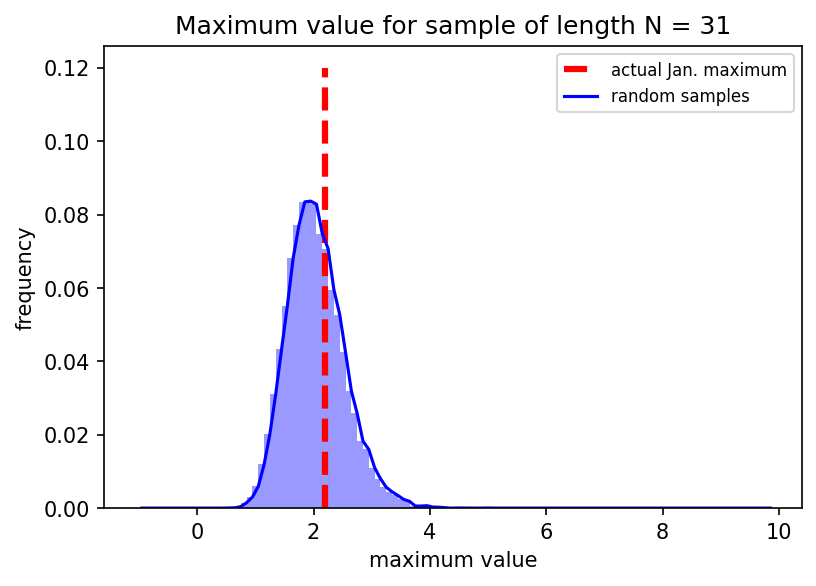

In [5]:
plt.figure()
bin_width = 0.1
bin_list = np.arange(-1, 10, bin_width)
n, bins = np.histogram(M, bins=bin_list, density=False)

plt.plot(
    [drawn_max, drawn_max],
    [0, 0.12],
    color="red",
    linewidth=3,
    linestyle="--",
    label="actual Jan. maximum",
)
plt.bar(bins[0:-1], n / float(len(M)), bin_width, facecolor="blue", alpha=0.4)
plt.plot(
    bins[0:-1] + bin_width / 2, n / float(len(M)), color="blue", label="random samples"
)

plt.xlabel("maximum value")
plt.ylabel("frequency")
plt.title(f"Maximum value for sample of length N = {sample_length}")
plt.legend(fontsize=8)
plt.show()

The blue curve is the distribution of maxima from random 31-day samples of a standard normal; the red dashed line is the observed January maximum. Eyeballing it, 2.2 looks *very* unsurprising — it's well inside the bulk of the simulated maxima.

To put a number on it, we compute the fraction of synthetic maxima that equaled or exceeded 2.2.


In [6]:
prob_exceed = 100.0 * float(np.sum(M > drawn_max)) / np.size(M)
print(f"P(max >= {drawn_max} sigma) = {prob_exceed:.1f}%")

P(max >= 2.2 sigma) = 35.7%


About **35%** of random 31-day samples produced a maximum at least as extreme as 2.2σ. So under the assumption that daily temperatures are normal, this January maximum is not at all unusual.


## Wrap-up

- Monte Carlo lets you build the null distribution of any statistic — even ones (like a sample maximum) that don't have a convenient textbook test — provided you're willing to specify the underlying distribution.
- The recipe is always the same: simulate → compute the statistic → repeat → read probabilities off the resulting histogram.
- For a 31-day standard-normal sample, a maximum of 2.2σ happens about a third of the time by chance, so it isn't evidence of anything unusual.
